# NLP Course 1 - Week 4 Alternative Assignment


## Machine Translation and Document Search with LSH

---

## Assignment Overview

**Your Mission**: Build two powerful real-world systems: (1) A machine translation model that translates English words to French using linear transformations of word embeddings, and (2) A lightning-fast document search engine using Locality Sensitive Hashing (LSH).

**The Grand Finale**: This week brings together everything from Weeks 1-3:

- **Week 1**: Text → Features (logistic regression)
- **Week 2**: Text → Probabilities (Naive Bayes)
- **Week 3**: Words → Vectors (embeddings & PCA)
- **Week 4**: Vectors → Translations & Fast Search (transformations & LSH)

**Real-World Impact**:

- Google Translate uses similar techniques
- Document search powers customer support bots
- LSH enables real-time similarity search at scale

**Expected Time**: 6-8 hours
**Difficulty**: Advanced (heavy on linear algebra and algorithms)

---



## Learning Objectives

By completing this assignment, you will:

1. **Linear transformations** - Transform vectors between language spaces
2. **Gradient descent** - Optimize transformation matrices
3. **Frobenius norm** - Measure transformation quality
4. **K-nearest neighbors** - Find similar vectors
5. **Hash tables** - Organize data for fast lookup
6. **Locality sensitive hashing** - Preserve similarity in hash buckets
7. **Multiple planes** - Create sophisticated hash functions
8. **Approximate search** - Trade accuracy for massive speed gains

---


## Core Concepts

### Part A: Machine Translation

**The Big Idea**: English and French word embeddings exist in different vector spaces, but we can learn a transformation matrix **R** that maps between them!

```
English Space          Transformation          French Space

"hello"                   Matrix R              "bonjour"
[0.2, 0.5, 0.3]    ─────────────────►    [0.3, 0.6, 0.4]
  (300D)                                        (300D)

"cat"                     Matrix R              "chat"
[0.1, 0.3, 0.7]    ─────────────────►    [0.2, 0.4, 0.8]
```

**Key insight**: Similar words in English should map to similar words in French!

### Part B: Locality Sensitive Hashing

**The Problem**: Finding similar documents in 10,000 tweets takes forever (compare every pair!)

**The Solution**: Use LSH to organize similar documents into same "buckets"

- Instead of checking 10,000 documents, only check ~50 in the same bucket
- **200x speedup!** ⚡

```
Without LSH:                  With LSH:
Compare query to             Hash query → Bucket 7
ALL 10,000 tweets            Only compare to ~50 tweets
SLOW                         FAST
```

---


## Datasets

### Part A: Bilingual Word Embeddings

**English embeddings**:

- 5,000 English words
- Each word = 300-dimensional vector
- Pre-trained on Google News

**French embeddings**:

- 5,000 French words
- Each word = 300-dimensional vector
- Pre-trained on French Wikipedia

**Training dictionary**:

- 5,000 English-French word pairs
- Example: `{"hello": "bonjour", "cat": "chat", ...}`

**Test dictionary**:

- 1,500 English-French pairs for evaluation

### Part B: Tweet Dataset

**All tweets**: 10,000 tweets

- Each tweet processed to remove noise
- Converted to document embeddings
- Each embedding = 300 dimensions

**Your task**: Given a query tweet, find the most similar tweets

---


### Imports and setup

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
import random
from typing import List, Dict, Tuple, Set
from sklearn.model_selection import train_test_split
import string  

import nltk
# download the stopwords from NLTK
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import pickle
from gensim.models import KeyedVectors
import time
from collections import defaultdict

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Run this only for the first time for setup and creating data

In [2]:
"""
Week 4 Dataset Setup - Machine Translation and LSH Document Search
"""

import os
import pickle
import numpy as np
import pandas as pd
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split

# Configuration
DATA_DIR = '../data'

# Toggle between full dataset and subset
USE_SUBSET = True  # Set to False to use full datasets

# Subset sizes (only used if USE_SUBSET = True)
SUBSET_EN_WORDS = 50000      # English vocabulary size
SUBSET_FR_WORDS = 50000      # French vocabulary size
TRAIN_PAIRS = 5000           # Training translation pairs
TEST_PAIRS = 1500            # Test translation pairs
NUM_TWEETS = 10000           # Number of tweets for LSH

print("Week 4 Dataset Setup")
print(f"Mode: {'SUBSET' if USE_SUBSET else 'FULL DATASET'}")
print()

# Step 1: Load Bilingual Dictionary
print("Step 1: Loading English-French dictionary")
dict_path = os.path.join(DATA_DIR, 'en-fr.txt')

en_fr_all = {}
with open(dict_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            en_fr_all[parts[0]] = parts[1]

print(f"Total dictionary pairs: {len(en_fr_all)}")

# Sample pairs
sample_pairs = list(en_fr_all.items())[:5]
print("Sample translations:")
for en, fr in sample_pairs:
    print(f"  {en} -> {fr}")
print()

Week 4 Dataset Setup
Mode: SUBSET

Step 1: Loading English-French dictionary
Total dictionary pairs: 94681
Sample translations:
  the -> la
  and -> et
  was -> était
  for -> pour
  that -> cela



In [3]:
# Step 2: Split into train/test
print("Step 2: Splitting train/test sets")
items = list(en_fr_all.items())
train_items, test_items = train_test_split(items, test_size=0.2, random_state=42)

if USE_SUBSET:
    en_fr_train = dict(train_items[:TRAIN_PAIRS])
    en_fr_test = dict(test_items[:TEST_PAIRS])
else:
    # Uncomment below to use full dataset
    # en_fr_train = dict(train_items)
    # en_fr_test = dict(test_items)
    en_fr_train = dict(train_items[:TRAIN_PAIRS])
    en_fr_test = dict(test_items[:TEST_PAIRS])

print(f"Training pairs: {len(en_fr_train)}")
print(f"Test pairs: {len(en_fr_test)}")
print()

Step 2: Splitting train/test sets
Training pairs: 5000
Test pairs: 1500



In [4]:
# Step 3: Load English Word Embeddings
print("Step 3: Loading English embeddings (this may take 2-3 minutes)")
en_embedding_path = os.path.join(DATA_DIR, 'GoogleNews-vectors-negative300.bin')

en_model = KeyedVectors.load_word2vec_format(en_embedding_path, binary=True)
print(f"Loaded English model: {len(en_model)} words")

if USE_SUBSET:
    # Extract only needed words for memory efficiency
    needed_en_words = set(en_fr_train.keys()) | set(en_fr_test.keys())
    en_embeddings = {}
    for word in needed_en_words:
        if word in en_model:
            en_embeddings[word] = en_model[word]
    print(f"Using subset: {len(en_embeddings)} words (from training/test sets)")
else:
    # Uncomment below to load full embeddings (requires ~6GB RAM)
    # en_embeddings = {word: en_model[word] for word in en_model.index_to_key}
    # print(f"Loaded full English embeddings: {len(en_embeddings)} words")
    needed_en_words = set(en_fr_train.keys()) | set(en_fr_test.keys())
    en_embeddings = {}
    for word in needed_en_words:
        if word in en_model:
            en_embeddings[word] = en_model[word]
    print(f"Using subset: {len(en_embeddings)} words")

# Show sample embedding
sample_word = list(en_embeddings.keys())[0]
sample_vec = en_embeddings[sample_word]
print(f"Sample: '{sample_word}' -> vector shape {sample_vec.shape}, mean={sample_vec.mean():.4f}")
print()

Step 3: Loading English embeddings (this may take 2-3 minutes)


KeyboardInterrupt: 

In [ ]:
# Step 4: Load French Word Embeddings
print("Step 4: Loading French embeddings (this may take 3-5 minutes)")
fr_embedding_path = os.path.join(DATA_DIR, 'cc.fr.300.bin')

# Check if file is gzipped
import gzip
if not os.path.exists(fr_embedding_path) and os.path.exists(fr_embedding_path + '.gz'):
    print("Extracting French embeddings from .gz file (one-time operation)")
    with gzip.open(fr_embedding_path + '.gz', 'rb') as f_in:
        with open(fr_embedding_path, 'wb') as f_out:
            f_out.write(f_in.read())
    print("Extraction complete")

fr_model = KeyedVectors.load_word2vec_format(fr_embedding_path, binary=True)
print(f"Loaded French model: {len(fr_model)} words")

if USE_SUBSET:
    # Extract only needed French words
    needed_fr_words = set(en_fr_train.values()) | set(en_fr_test.values())
    fr_embeddings = {}
    for word in needed_fr_words:
        if word in fr_model:
            fr_embeddings[word] = fr_model[word]
    print(f"Using subset: {len(fr_embeddings)} words (from training/test sets)")
else:
    # Uncomment below to load full embeddings (requires ~8GB RAM)
    # fr_embeddings = {word: fr_model[word] for word in fr_model.index_to_key}
    # print(f"Loaded full French embeddings: {len(fr_embeddings)} words")
    needed_fr_words = set(en_fr_train.values()) | set(en_fr_test.values())
    fr_embeddings = {}
    for word in needed_fr_words:
        if word in fr_model:
            fr_embeddings[word] = fr_model[word]
    print(f"Using subset: {len(fr_embeddings)} words")

# Show sample embedding
sample_word_fr = list(fr_embeddings.keys())[0]
sample_vec_fr = fr_embeddings[sample_word_fr]
print(f"Sample: '{sample_word_fr}' -> vector shape {sample_vec_fr.shape}, mean={sample_vec_fr.mean():.4f}")
print()

Step 4: Loading French embeddings (this may take 3-5 minutes)
Extracting French embeddings from .gz file (one-time operation)


In [ ]:
# Step 5: Check alignment and create matched pairs
print("Step 5: Validating alignment")
valid_train = 0
valid_test = 0

for en, fr in en_fr_train.items():
    if en in en_embeddings and fr in fr_embeddings:
        valid_train += 1

for en, fr in en_fr_test.items():
    if en in en_embeddings and fr in fr_embeddings:
        valid_test += 1

print(f"Valid training pairs: {valid_train}/{len(en_fr_train)} ({valid_train/len(en_fr_train)*100:.1f}%)")
print(f"Valid test pairs: {valid_test}/{len(en_fr_test)} ({valid_test/len(en_fr_test)*100:.1f}%)")
print()

# Step 6: Load Tweets
print("Step 6: Loading tweets for LSH")
tweets_path = os.path.join(DATA_DIR, 'training.1600000.processed.noemoticon.csv')

df = pd.read_csv(
    tweets_path,
    encoding='latin-1',
    header=None,
    names=['target', 'id', 'date', 'flag', 'user', 'text']
)

if USE_SUBSET:
    all_tweets = df['text'].tolist()[:NUM_TWEETS]
    print(f"Loaded {len(all_tweets)} tweets (subset)")
else:
    # Uncomment below to use full tweet dataset (requires ~2GB RAM)
    # all_tweets = df['text'].tolist()
    # print(f"Loaded {len(all_tweets)} tweets (full dataset)")
    all_tweets = df['text'].tolist()[:NUM_TWEETS]
    print(f"Loaded {len(all_tweets)} tweets")

# Show sample tweets
print("Sample tweets:")
for i, tweet in enumerate(all_tweets[:3], 1):
    print(f"  {i}. {tweet[:70]}...")

# Calculate average tweet length
avg_length = np.mean([len(tweet.split()) for tweet in all_tweets[:1000]])
print(f"Average tweet length: {avg_length:.1f} words")
print()

# Step 7: Save processed data
print("Step 7: Saving processed data")

save_dir = os.path.join(DATA_DIR, 'processed')
os.makedirs(save_dir, exist_ok=True)

# Save dictionaries
with open(os.path.join(save_dir, 'en_fr_train.pkl'), 'wb') as f:
    pickle.dump(en_fr_train, f)

with open(os.path.join(save_dir, 'en_fr_test.pkl'), 'wb') as f:
    pickle.dump(en_fr_test, f)

# Save embeddings
with open(os.path.join(save_dir, 'en_embeddings.pkl'), 'wb') as f:
    pickle.dump(en_embeddings, f)

with open(os.path.join(save_dir, 'fr_embeddings.pkl'), 'wb') as f:
    pickle.dump(fr_embeddings, f)

# Save tweets
with open(os.path.join(save_dir, 'tweets.pkl'), 'wb') as f:
    pickle.dump(all_tweets, f)

print(f"Saved to {save_dir}/")
print()

# Final Summary
print("Dataset Setup Complete")
print(f"Mode: {'SUBSET' if USE_SUBSET else 'FULL'}")
print()
print("Data shapes and sizes:")
print(f"  en_fr_train: {len(en_fr_train)} pairs")
print(f"  en_fr_test: {len(en_fr_test)} pairs")
print(f"  en_embeddings: {len(en_embeddings)} words x 300D")
print(f"  fr_embeddings: {len(fr_embeddings)} words x 300D")
print(f"  all_tweets: {len(all_tweets)} tweets")
print()

# Quick load instructions
print("To load in your notebook:")
print("""
import pickle

# Load data
with open('../data/processed/en_fr_train.pkl', 'rb') as f:
    en_fr_train = pickle.load(f)
    
with open('../data/processed/en_fr_test.pkl', 'rb') as f:
    en_fr_test = pickle.load(f)
    
with open('../data/processed/en_embeddings.pkl', 'rb') as f:
    en_embeddings = pickle.load(f)
    
with open('../data/processed/fr_embeddings.pkl', 'rb') as f:
    fr_embeddings = pickle.load(f)
    
with open('../data/processed/tweets.pkl', 'rb') as f:
    all_tweets = pickle.load(f)
""")

### Dataset for local machine - (low)

In [ ]:
"""
Week 4 Dataset Setup
Simple version for loading English and French word embeddings
"""

import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Configuration
DATA_DIR = '../data'
TRAIN_PAIRS = 10000  
TEST_PAIRS = 3000    
NUM_TWEETS = 20000   
FRENCH_MODEL_NAME = 'wiki.fr.vec'

print("Week 4 Dataset Setup")
print()

# Step 1: Load bilingual dictionary
print("Step 1: Loading English-French dictionary")
dict_path = os.path.join(DATA_DIR, 'en-fr.txt')

en_fr_all = {}
with open(dict_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            en_fr_all[parts[0]] = parts[1]

print(f"Total pairs: {len(en_fr_all)}")
print("Sample:", list(en_fr_all.items())[:3])
print()

# Step 2: Split into train and test sets
print("Step 2: Creating train and test sets")
items = list(en_fr_all.items())
train_items, test_items = train_test_split(items, test_size=0.25, random_state=42)

en_fr_train = dict(train_items[:TRAIN_PAIRS])
en_fr_test = dict(test_items[:TEST_PAIRS])

print(f"Training pairs: {len(en_fr_train)}")
print(f"Test pairs: {len(en_fr_test)}")
print()

# Step 3: Load English embeddings
print("Step 3: Loading English embeddings")
en_embedding_path = os.path.join(DATA_DIR, 'GoogleNews-vectors-negative300.bin')

needed_en_words = set(en_fr_train.keys()) | set(en_fr_test.keys())
print(f"Need {len(needed_en_words)} English words")

en_embeddings = {}

try:
    from gensim.models import KeyedVectors
    
    en_model = KeyedVectors.load_word2vec_format(en_embedding_path, binary=True)
    
    for word in needed_en_words:
        if word in en_model:
            en_embeddings[word] = en_model[word].copy()
    
    # Load tweet embeddings
    print("\nStep 3b: Loading tweet embeddings for LSH")
    print("Extracting top 50,000 common words...")

    en_embeddings_tweets = {}
    for word in en_model.index_to_key[:50000]:
        en_embeddings_tweets[word] = en_model[word].copy()

    print(f"Loaded {len(en_embeddings_tweets)} tweet embeddings")

    # Test that it worked
    if len(en_embeddings_tweets) > 0:
        sample_word = list(en_embeddings_tweets.keys())[0]
        sample_vec = en_embeddings_tweets[sample_word]
        print(f"Sample: '{sample_word}' → vector shape {sample_vec.shape}")
    else:
        print("⚠️ WARNING: Tweet embeddings dictionary is empty!")

    del en_model
    
    print(f"Loaded {len(en_embeddings)} English embeddings")
    
except Exception as e:
    print(f"Error: {e}")

print()

# Step 4: Load French embeddings
print("Step 4: Loading French embeddings")

fr_embedding_path = os.path.join(DATA_DIR, FRENCH_MODEL_NAME)

if not os.path.exists(fr_embedding_path):
    print(f"File not found: {fr_embedding_path}")
    print("Download from: https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.fr.vec")
    fr_embeddings = {}
else:
    needed_fr_words = set(en_fr_train.values()) | set(en_fr_test.values())
    print(f"Need {len(needed_fr_words)} French words")
    print(f"File size: {os.path.getsize(fr_embedding_path) / (1024**3):.2f} GB")
    print("Loading (this takes 2-3 minutes)...")
    
    fr_embeddings = {}
    
    try:
        lines_read = 0
        words_found = 0
        
        with open(fr_embedding_path, 'r', encoding='utf-8') as f:
            first_line = f.readline().strip().split()
            vocab_size = int(first_line[0])
            dim = int(first_line[1])
            
            print(f"File contains {vocab_size:,} words with {dim}D vectors")
            
            for line in f:
                lines_read += 1
                parts = line.strip().split()
                
                if len(parts) < 2:
                    continue
                
                word = parts[0]
                
                if word in needed_fr_words:
                    try:
                        vector = np.array([float(x) for x in parts[1:]], dtype=np.float32)
                        
                        if vector.shape[0] == dim:
                            fr_embeddings[word] = vector
                            words_found += 1
                            
                            if words_found % 500 == 0:
                                print(f"Found {words_found}/{len(needed_fr_words)} words")
                    except ValueError:
                        continue
                
                if lines_read % 50000 == 0:
                    print(f"Scanned {lines_read:,} lines, found {words_found} words")
                
                if words_found == len(needed_fr_words):
                    print(f"All words found at line {lines_read:,}")
                    break
        
        print(f"Loaded {len(fr_embeddings)} French embeddings")
        
    except Exception as e:
        print(f"Error: {e}")

print()

# Step 5: Validate alignment
print("Step 5: Checking alignment")
valid_train = sum(1 for en, fr in en_fr_train.items() 
                  if en in en_embeddings and fr in fr_embeddings)
valid_test = sum(1 for en, fr in en_fr_test.items() 
                 if en in en_embeddings and fr in fr_embeddings)

print(f"Valid training pairs: {valid_train}/{len(en_fr_train)} ({valid_train/len(en_fr_train)*100:.1f}%)")
print(f"Valid test pairs: {valid_test}/{len(en_fr_test)} ({valid_test/len(en_fr_test)*100:.1f}%)")
print()

# Step 6: Load tweets
print("Step 6: Loading tweets")
tweets_path = os.path.join(DATA_DIR, 'training.1600000.processed.noemoticon.csv')

try:
    df = pd.read_csv(
        tweets_path,
        encoding='latin-1',
        header=None,
        names=['target', 'id', 'date', 'flag', 'user', 'text'],
        nrows=NUM_TWEETS
    )
    
    all_tweets = df['text'].tolist()
    print(f"Loaded {len(all_tweets)} tweets")
    print(f"Sample: {all_tweets[0][:60]}...")
    
except Exception as e:
    print(f"Error: {e}")
    all_tweets = []

print()

# Step 7: Save processed data
print("Step 7: Saving processed data")

save_dir = os.path.join(DATA_DIR, 'processed')
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, 'en_fr_train.pkl'), 'wb') as f:
    pickle.dump(en_fr_train, f)

with open(os.path.join(save_dir, 'en_fr_test.pkl'), 'wb') as f:
    pickle.dump(en_fr_test, f)

with open(os.path.join(save_dir, 'en_embeddings.pkl'), 'wb') as f:
    pickle.dump(en_embeddings, f)

with open(os.path.join(save_dir, 'fr_embeddings.pkl'), 'wb') as f:
    pickle.dump(fr_embeddings, f)

with open(os.path.join(save_dir, 'tweets.pkl'), 'wb') as f:
    pickle.dump(all_tweets, f)

with open(os.path.join(save_dir, 'en_embeddings_tweets.pkl'), 'wb') as f:
    pickle.dump(en_embeddings_tweets, f)

print(f"Saved to {save_dir}")
print()

# Summary
print("Setup complete")
print()
print("Data loaded:")
print(f"  Training pairs: {len(en_fr_train)}")
print(f"  Test pairs: {len(en_fr_test)}")
print(f"  English embeddings: {len(en_embeddings)} words")
print(f"  French embeddings: {len(fr_embeddings)} words")
print(f"  Tweets: {len(all_tweets)}")
print(f"  Valid training pairs: {valid_train} ({valid_train/len(en_fr_train)*100:.1f}%)")
print(f"  Valid test pairs: {valid_test} ({valid_test/len(en_fr_test)*100:.1f}%)")
print()

if valid_train > 0:
    print("Success! Ready for Week 4 assignment")
    print()
else:
    print("Failed: No valid training pairs found")

Week 4 Dataset Setup

Step 1: Loading English-French dictionary
Total pairs: 94681
Sample: [('the', 'la'), ('and', 'et'), ('was', 'était')]

Step 2: Creating train and test sets
Training pairs: 10000
Test pairs: 3000

Step 3: Loading English embeddings
Need 13000 English words

Step 3b: Loading tweet embeddings for LSH
Extracting top 50,000 common words...
Loaded 50000 tweet embeddings
Sample: '</s>' → vector shape (300,)
Loaded 5515 English embeddings

Step 4: Loading French embeddings
Need 12839 French words
File size: 2.82 GB
Loading (this takes 2-3 minutes)...
File contains 1,152,449 words with 300D vectors
Found 500/12839 words
Found 1000/12839 words
Found 1500/12839 words
Found 2000/12839 words
Found 2500/12839 words
Found 3000/12839 words
Found 3500/12839 words
Found 4000/12839 words
Found 4500/12839 words
Scanned 50,000 lines, found 4706 words
Found 5000/12839 words
Found 5500/12839 words
Found 6000/12839 words
Found 6500/12839 words
Found 7000/12839 words
Found 7500/12839 word

### Load the data

In [67]:
def load_week4_data():
    import pickle
    
    data_dir = '../data/processed'
    
    with open(f'{data_dir}/en_fr_train.pkl', 'rb') as f:
        en_fr_train = pickle.load(f)
    with open(f'{data_dir}/en_fr_test.pkl', 'rb') as f:
        en_fr_test = pickle.load(f)
    with open(f'{data_dir}/en_embeddings.pkl', 'rb') as f:
        en_embeddings = pickle.load(f)
    with open(f'{data_dir}/fr_embeddings.pkl', 'rb') as f:
        fr_embeddings = pickle.load(f)
    with open(f'{data_dir}/en_embeddings_tweets.pkl', 'rb') as f: 
        en_embeddings_tweets = pickle.load(f)
    with open(f'{data_dir}/tweets.pkl', 'rb') as f:
        all_tweets = pickle.load(f)
    
    return en_fr_train, en_fr_test, en_embeddings, fr_embeddings, en_embeddings_tweets, all_tweets

en_fr_train, en_fr_test, en_embeddings, fr_embeddings, en_embeddings_tweets, all_tweets = load_week4_data()

## Part 1: Building the Translation System


### Milestone 1.1: Prepare Training Matrices

**What to implement**: Create `get_matrices(en_fr_dict, en_embeddings, fr_embeddings)` function

**The alignment is crucial**:

```
X (English)              Y (French)
Row 0: "hello" vector    Row 0: "bonjour" vector  Aligned
Row 1: "cat" vector      Row 1: "chat" vector     Aligned
Row 2: "dog" vector      Row 2: "chien" vector    Aligned
```

**GOTCHA #1**: Not all words have embeddings!

- Some English words might not be in `en_embeddings`
- Some French words might not be in `fr_embeddings`
- **Only include pairs where BOTH words have embeddings**
- Otherwise matrix multiplication will fail

**Algorithm:**

```
1. Initialize empty lists: X_list = [], Y_list = []
2. For each (english_word, french_word) in en_fr_dict:
    a. Check if english_word in en_embeddings
    b. Check if french_word in fr_embeddings
    c. If BOTH exist:
        - Append en_embeddings[english_word] to X_list
        - Append fr_embeddings[french_word] to Y_list
3. Stack lists into matrices:
    X = np.vstack(X_list)
    Y = np.vstack(Y_list)
4. Return X, Y
```

**Hints**:

- Use sets for fast membership checking: `english_set = set(en_embeddings.keys())`
- Use `np.vstack()` to stack vectors into matrix
- Verify alignment: X[i] should correspond to Y[i]

**Concepts from Week 4 Material**:

- Transforming word vectors (Section 2)
- Matrix preparation for learning
- Aligned data structures

---


In [68]:
def get_matrices(en_fr_dict, en_embeddings, fr_embeddings):
    """
    Build aligned matrices of English and French embeddings

    Args:
        en_fr_dict: Dictionary mapping English words to French
                    Example: {"hello": "bonjour", "cat": "chat"}
        en_embeddings: Dictionary of English word vectors
        fr_embeddings: Dictionary of French word vectors

    Returns:
        X: Matrix where each row is an English word embedding
           Shape: (n, 300) where n = number of word pairs
        Y: Matrix where each row is the corresponding French embedding
           Shape: (n, 300)

    Note: Row i in X corresponds to row i in Y (aligned!)
    """
    X_list = []
    Y_list = []

    english_set = set(en_embeddings.keys())
    french_set = set(fr_embeddings.keys())

    for english_word, french_word in en_fr_dict.items():
        if english_word in english_set and french_word in french_set:
            X_list.append(en_embeddings[english_word])
            Y_list.append(fr_embeddings[french_word])

    X = np.vstack(X_list)
    Y = np.vstack(Y_list)

    return X, Y

**Test your function:**

In [69]:
# Create small test case
test_en_fr = {"hello": "bonjour", "cat": "chat", "dog": "chien"}
test_en_embeddings = {
    "hello": np.array([1, 2, 3]),
    "cat": np.array([4, 5, 6]),
    "dog": np.array([7, 8, 9])
}
test_fr_embeddings = {
    "bonjour": np.array([1.1, 2.1, 3.1]),
    "chat": np.array([4.1, 5.1, 6.1]),
    "chien": np.array([7.1, 8.1, 9.1])
}

X, Y = get_matrices(test_en_fr, test_en_embeddings, test_fr_embeddings)

# Verify shapes
assert X.shape == (3, 3)
assert Y.shape == (3, 3)

# Verify alignment
assert np.allclose(X[0], [1, 2, 3])  # "hello"
assert np.allclose(Y[0], [1.1, 2.1, 3.1])  # "bonjour"

print("Matrix preparation tests passed!")

Matrix preparation tests passed!


### Milestone 1.2: Initialize Transformation Matrix

**What to implement**: Create `initialize_transformation_matrix(d)` function

**Why random initialization?**

- We don't know the optimal transformation yet
- Random start + gradient descent → learns optimal R
- Similar to initializing neural network weights

**GOTCHA #2**: Scale matters!

- Don't initialize with zeros (no learning signal)
- Don't initialize too large (exploding gradients)
- Good range: [-0.01, 0.01] or use Xavier initialization

**Hints**:

- Use `np.random.seed()` for reproducibility
- Scale: `R = np.random.rand(d, d) * 0.01`
- Or: `R = np.random.randn(d, d) / np.sqrt(d)` (Xavier)

---


In [70]:
def initialize_transformation_matrix(d):
    """
    Initialize transformation matrix R with random values

    Args:
        d: Dimension of word embeddings (typically 300)

    Returns:
        R: Random matrix of shape (d, d)
           Initialized with small random values
    """
    # Xavier initialization
    R = np.random.randn(d,d) / np.sqrt(d)
    return R

**Test your function:**

In [71]:
np.random.seed(42)
R = initialize_transformation_matrix(300)

# Check shape
assert R.shape == (300, 300)

# Check value range
assert -1 < np.mean(R) < 1
assert np.std(R) < 1

print(f"Initialized R with shape {R.shape}")
print(f"  Mean: {np.mean(R):.6f}, Std: {np.std(R):.6f}")

Initialized R with shape (300, 300)
  Mean: 0.000095, Std: 0.057809


### Milestone 1.3: Implement Loss Function

**What to implement**: Create `compute_loss(X, Y, R)` function

**Mathematical Foundation**:

The **Frobenius norm squared** measures how far transformed English vectors are from French vectors:

$$\text{Loss} = \frac{1}{m} ||XR - Y||^2_F = \frac{1}{m} \sum_{i=1}^{m} \sum_{j=1}^{d} (X_i R - Y_i)_{j}^2$$

**Intuition**:

- Transform English: `XR`
- Compare to French: `XR - Y`
- Square all differences: `(XR - Y)²`
- Sum everything: Frobenius norm
- Average: divide by m

**GOTCHA #3**: Frobenius norm vs regular norm

- Frobenius norm: Sum of all squared elements
- `||A||²_F = sum(A**2)` for all elements
- NOT the same as `np.linalg.norm(A)` (that's vector norm!)

**Hints**:

- Use `np.dot(X, R)` for matrix multiplication
- Frobenius norm: `np.sum((XR - Y)**2)`
- Don't forget to divide by m!

**Concepts from Week 4 Material**:

- Loss functions for transformation
- Frobenius norm
- Matrix operations

---


In [72]:
def compute_loss(X, Y, R):
    """
    Compute Frobenius norm loss for transformation

    Args:
        X: English word matrix (m, d)
        Y: French word matrix (m, d)
        R: Transformation matrix (d, d)

    Returns:
        loss: Scalar loss value (how bad our transformation is)

    Formula:
        loss = ||XR - Y||²_F / m
    """
    # print("m = ",m)

    XR =  np.dot(X, R)

    # print("XR = ",XR)

    diff = XR - Y

    squared = diff**2

    frobenius_squared = np.sum(squared)

    m = X.shape[0]
    loss = frobenius_squared / m

    # print("loss = ",loss)

    return loss

**Test your function:**

In [73]:
# Simple test case
X = np.array([[1, 2], [3, 4]])  # 2x2
Y = np.array([[2, 3], [4, 5]])  # 2x2
R = np.eye(2)  # Identity matrix

loss = compute_loss(X, Y, R)
# XR = X, diff = X - Y = [[-1,-1],[-1,-1]]
# Frobenius = 4, m = 2, loss = 4/2 = 2
assert abs(loss - 2.0) < 1e-6

print("Loss function test passed!")

Loss function test passed!


### Milestone 1.4: Implement Gradient Computation

**What to implement**: Create `compute_gradient(X, Y, R)` function

**Mathematical Foundation**:

Gradient of Frobenius norm loss:

$$\frac{\partial L}{\partial R} = \frac{2}{m} X^T (XR - Y)$$

**Derivation intuition** (you don't need to derive it):

- Loss: $L = \frac{1}{m}||XR - Y||^2_F$
- Chain rule: $\frac{\partial}{\partial R} ||XR - Y||^2 = 2(XR - Y) \cdot \frac{\partial(XR)}{\partial R}$
- Matrix calculus: $\frac{\partial(XR)}{\partial R} = X^T$
- Result: $\frac{2}{m} X^T(XR - Y)$

**GOTCHA #4**: Matrix dimensions!

- X: (m, d)
- R: (d, d)
- Y: (m, d)
- XR: (m, d)
- (XR - Y): (m, d)
- X^T: (d, m)
- **Gradient: (d, m) × (m, d) = (d, d)** 

**Hints**:

- `X.T` gives transpose
- Matrix multiply: `np.dot(X.T, error)`
- Check shapes: gradient should be (d, d)

**Concepts from Week 4 Material**:

- Gradient descent for transformations
- Matrix calculus
- Optimization

---


In [74]:
def compute_gradient(X, Y, R):
    """
    Compute gradient of loss with respect to R

    Args:
        X: English word matrix (m, d)
        Y: French word matrix (m, d)
        R: Current transformation matrix (d, d)

    Returns:
        grad: Gradient matrix (d, d)
              Direction to update R to minimize loss

    Formula:
        grad = (2/m) * X^T * (XR - Y)
    """
    XR =  np.dot(X, R)
    error = XR - Y
    
    grad = np.dot(X.T, error)

    m = X.shape[0]

    grad = ( 2/m ) * grad

    return grad

**Test your function:**

In [75]:
# Simple test with known gradient
X = np.array([[1, 0], [0, 1]])  # 2x2 identity
Y = np.array([[2, 0], [0, 2]])  # 2x2 scaled
R = np.eye(2)  # Current R

grad = compute_gradient(X, Y, R)

# XR = I, error = I - 2I = -I
# X^T = I, grad = (2/2) * I * (-I) = -I
expected = -np.eye(2)
assert np.allclose(grad, expected)

print("Gradient computation test passed")

Gradient computation test passed


### Milestone 1.5: Train Transformation Matrix

**What to implement**: Create `align_embeddings(X, Y, learning_rate, epochs)` function

**Algorithm: Gradient Descent**

```
1. Initialize R randomly
2. For each epoch:
    a. Compute loss: L = compute_loss(X, Y, R)
    b. Compute gradient: grad = compute_gradient(X, Y, R)
    c. Update R: R = R - learning_rate * grad
    d. Record loss for monitoring
3. Return final R and loss history
```

**GOTCHA #5**: Learning rate tuning!

- Too small (1e-6): Training too slow, won't converge in 100 epochs
- Too large (1.0): Training unstable, loss explodes
- Good range: 1e-4 to 1e-3
- Start with 3e-4 (0.0003)

**Hints**:

- Monitor loss - it should decrease!
- If loss increases: learning rate too high
- If loss flat: learning rate too low or need more epochs
- Plot loss curve to diagnose issues

**Concepts from Week 4 Material**:

- Gradient descent optimization
- Learning rate selection
- Training monitoring

---


In [76]:
def align_embeddings(X, Y, learning_rate=0.0003, epochs=100):
    """
    Learn optimal transformation matrix R using gradient descent

    Args:
        X: English word matrix (m, d)
        Y: French word matrix (m, d)
        learning_rate: Step size for gradient descent
        epochs: Number of training iterations

    Returns:
        R: Learned transformation matrix (d, d)
        losses: List of loss values over training (for plotting)
    """
    # dimension of the embeddings
    m, d = X.shape
    R = initialize_transformation_matrix(d)

    losses = []

    for epoch in range(epochs):
        # forward pass: compute loss
        L = compute_loss(X, Y,R)
        losses.append(L)

        # backward pass: compute gradient
        grad = compute_gradient(X, Y, R)

        # update R
        R = R - (learning_rate * grad)
        
        # print progress every 25 epochs
        if epoch % 25 == 0:
            print(f"Epoch {epoch+1}/{epochs}: Loss = {L:.4f}")

    return R, losses
    

**Test your function:**

Training on 4230 word pairs...
Epoch 1/1000: Loss = 32.9573
Epoch 26/1000: Loss = 29.5991
Epoch 51/1000: Loss = 27.6912
Epoch 76/1000: Loss = 26.4714
Epoch 101/1000: Loss = 25.5955
Epoch 126/1000: Loss = 24.9052
Epoch 151/1000: Loss = 24.3256
Epoch 176/1000: Loss = 23.8197
Epoch 201/1000: Loss = 23.3675
Epoch 226/1000: Loss = 22.9577
Epoch 251/1000: Loss = 22.5827
Epoch 276/1000: Loss = 22.2373
Epoch 301/1000: Loss = 21.9176
Epoch 326/1000: Loss = 21.6204
Epoch 351/1000: Loss = 21.3433
Epoch 376/1000: Loss = 21.0839
Epoch 401/1000: Loss = 20.8406
Epoch 426/1000: Loss = 20.6117
Epoch 451/1000: Loss = 20.3959
Epoch 476/1000: Loss = 20.1920
Epoch 501/1000: Loss = 19.9991
Epoch 526/1000: Loss = 19.8161
Epoch 551/1000: Loss = 19.6423
Epoch 576/1000: Loss = 19.4770
Epoch 601/1000: Loss = 19.3196
Epoch 626/1000: Loss = 19.1694
Epoch 651/1000: Loss = 19.0261
Epoch 676/1000: Loss = 18.8890
Epoch 701/1000: Loss = 18.7579
Epoch 726/1000: Loss = 18.6323
Epoch 751/1000: Loss = 18.5119
Epoch 776/100

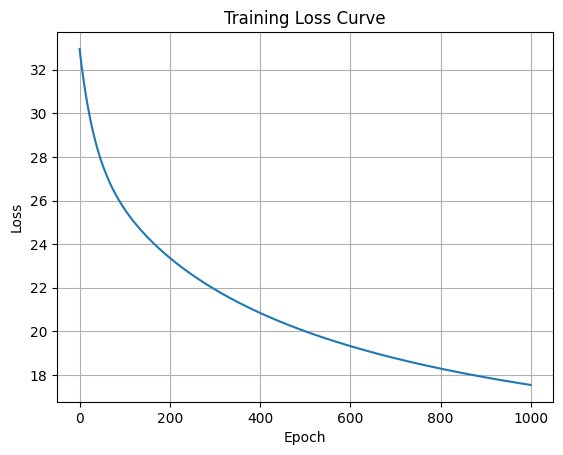

Training complete!
   Initial loss: 32.9573
   Final loss: 17.5387
   Improvement: 15.4187


In [77]:
# Train on small dataset
X_train, Y_train = get_matrices(en_fr_train, en_embeddings, fr_embeddings)

print(f"Training on {X_train.shape[0]} word pairs...")
R, losses = align_embeddings(X_train, Y_train, learning_rate=0.01, epochs=1000)

# Verify loss decreased
assert losses[0] > losses[-1], "Loss should decrease during training!"

# Plot loss curve
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.grid(True)
plt.show()

print(f"Training complete!")
print(f"   Initial loss: {losses[0]:.4f}")
print(f"   Final loss: {losses[-1]:.4f}")
print(f"   Improvement: {losses[0] - losses[-1]:.4f}")

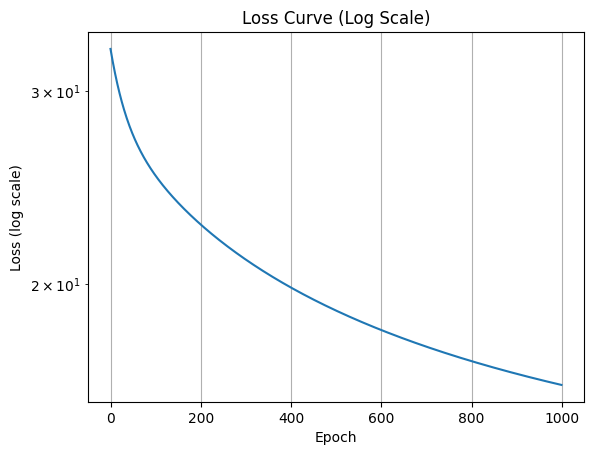

In [13]:
plt.semilogy(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Loss Curve (Log Scale)")
plt.grid(True)
plt.show()

## Part 2: Testing Translation Quality


### Milestone 2.1: Find Nearest Neighbor

**What to implement**: Create `nearest_neighbor(v, candidates, k=1)` function

**Algorithm:**

```
1. Compute similarity between v and each candidate:
    For i in range(n):
        similarity[i] = cosine_similarity(v, candidates[i])
2. Sort by similarity (descending)
3. Return top k indices
```

**GOTCHA #6**: Cosine vs Euclidean!

- For word embeddings, use **cosine similarity**
- Cosine measures direction (semantics)
- Euclidean measures distance (magnitude + direction)
- Review Week 3 if needed!

**Concepts from Week 3-4 Material**:

- K-nearest neighbors (Week 4, Section 4)
- Cosine similarity (Week 3, Section 5)
- Vector operations

---


### cosine similarity

In [78]:
def cosine_similarity(a, b):
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    return dot / (norm_a * norm_b)

In [79]:
def nearest_neighbor(v, candidates, k=1):
    """
    Find k nearest neighbors to vector v

    Args:
        v: Query vector (d,)
        candidates: Matrix of candidate vectors (n, d)
        k: Number of neighbors to return

    Returns:
        indices: List of k indices into candidates
                 Sorted by similarity (closest first)
    """
    # compute similarities for all candidates
    similarities = []

    for i in range(candidates.shape[0]):
        candidate = candidates[i]
        sim = cosine_similarity(v, candidate)
        similarities.append((i, sim))

    # sort by similarity (descending)
    similarities.aort(key=lambda x:x[1], reverse=True)

    # return top k indices
    indices = [idx for idx,sim in similarities[:k]]

    return indices
    

### vectorized_version (faster)

In [80]:
def nearest_neighbor(v, candidates, k=1):
    """
    Find k nearest neighbors using cosine similarity
    """
    # Handle zero vectors - add epsilon to avoid division by zero
    epsilon = 1e-10
    
    # Normalize query vector
    v_norm_val = np.linalg.norm(v)
    if v_norm_val < epsilon:
        # If query is zero vector, return random indices
        return np.random.choice(len(candidates), size=min(k, len(candidates)), replace=False)
    v_norm = v / v_norm_val
    
    # Normalize candidate vectors
    candidates_norm_vals = np.linalg.norm(candidates, axis=1, keepdims=True)
    candidates_norm_vals = np.where(candidates_norm_vals < epsilon, 1.0, candidates_norm_vals)  # Replace zeros with 1
    candidates_norm = candidates / candidates_norm_vals
    
    # Compute cosine similarity
    similarities = np.dot(candidates_norm, v_norm)
    
    # Get indices of top k
    indices = np.argsort(similarities)[::-1][:k]
    
    return indices


**Test your function:**

In [81]:
# Simple test
query = np.array([1, 1, 1])
candidates = np.array([
    [1, 1, 1],     # Identical - should be rank 1
    [1, 1, 0],     # Similar - should be rank 2
    [-1, -1, -1],  # Opposite - should be rank 3
    [0, 0, 0]      # Zero vector
])

indices = nearest_neighbor(query, candidates[1:], k=3)  # Skip identical

print(f"Nearest neighbors to {query}:")
for i, idx in enumerate(indices):
    print(f"   Rank {i+1}: Candidate {idx} = {candidates[idx+1]}")

Nearest neighbors to [1 1 1]:
   Rank 1: Candidate 0 = [1 1 0]
   Rank 2: Candidate 2 = [0 0 0]
   Rank 3: Candidate 1 = [-1 -1 -1]


### Milestone 2.2: Translate a Word

**What to implement**: Create `translate_word(word, R, en_embeddings, fr_embeddings, k=5)` function

**Algorithm:**

```
1. Get English embedding: v_en = en_embeddings[word]
2. Transform to French space: v_transformed = R @ v_en
3. Get all French vectors as matrix
4. Find k nearest neighbors in French vectors
5. Return French words with their similarities
```

**GOTCHA #7**: Matrix multiplication order!

- R is (d, d)
- v_en is (d,) or (d, 1)
- Correct: `v_transformed = R @ v_en` or `v_transformed = np.dot(R, v_en)`
- Wrong: `v_en @ R` (dimension mismatch!)

**Concepts from Week 4 Material**:

- Word vector transformation
- Nearest neighbor search
- Machine translation pipeline

---


In [82]:
def translate_word(word, R, en_embeddings, fr_embeddings, k=5):
    """
    Translate an English word to French

    Args:
        word: English word (string)
        R: Learned transformation matrix (d, d)
        en_embeddings: English word vectors
        fr_embeddings: French word vectors
        k: Number of translation candidates

    Returns:
        candidates: List of (french_word, similarity) tuples
    """
    # check if word exists
    if word not in en_embeddings:
        print("word not in embeddings")
        return []

    # get english embedding for the eng word
    v_en = en_embeddings[word]

    # transform to french space
    v_transformed = np.dot(v_en, R)

    # get all french words and their vectors
    french_words = list(fr_embeddings.keys())
    french_vectors = np.array([fr_embeddings[w] for w in french_words])

    # find k nearest neighbors
    indices = nearest_neighbor(v_transformed, french_vectors, k=k)

    # create result list with similarities
    candidates = []
    v_transformed_norm = v_transformed / np.linalg.norm(v_transformed)

    for idx in indices:
        french_word = french_words[idx]
        french_vec = french_vectors[idx]
        french_vec_norm = french_vec / np.linalg.norm(french_vec)
        similarity = np.dot(v_transformed_norm, french_vec_norm)    # cosine similarity
        candidates.append((french_word, similarity))

    return candidates

**Test your function:**

In [83]:
# Test translation
test_words = ["hello", "boyfriend", "academic", "gravel", "salad"]

print("TRANSLATION TESTS\n")
for word in test_words:
    translations = translate_word(word, R, en_embeddings, fr_embeddings, k=3)
    print(f"{word}:")
    for french_word, sim in translations:
        print(f"  → {french_word} (similarity: {sim:.3f})")
    print()

TRANSLATION TESTS

hello:
  → wynette (similarity: 0.536)
  → hutchence (similarity: 0.533)
  → arrivederci (similarity: 0.528)

boyfriend:
  → complice (similarity: 0.611)
  → copain (similarity: 0.599)
  → babysitter (similarity: 0.581)

academic:
  → interdisciplinaire (similarity: 0.567)
  → académique (similarity: 0.551)
  → mathématiques (similarity: 0.547)

gravel:
  → graviers (similarity: 0.670)
  → remblai (similarity: 0.608)
  → dalles (similarity: 0.567)

salad:
  → braisé (similarity: 0.656)
  → épinards (similarity: 0.651)
  → poireaux (similarity: 0.640)



### Milestone 2.3: Evaluate Translation Accuracy

**What to implement**: Create `test_vocabulary(test_dict, R, en_embeddings, fr_embeddings)` function

**Algorithm:**

```
1. Initialize: correct = 0, errors = []
2. For each (english_word, true_french_word) in test_dict:
    a. Translate: candidates = translate_word(english_word, ...)
    b. Get prediction: predicted_french = candidates[0][0]
    c. If predicted_french == true_french_word:
        - Increment correct
    d. Else:
        - Add to errors list with details
3. accuracy = correct / total
4. Return accuracy and errors
```

**GOTCHA #8**: Not all words in test dict!

- Some test words may not be in embeddings
- Skip words without embeddings (don't count as errors)
- Only evaluate on words that CAN be translated

**Expected accuracy**: 50-60% for top-1 (this is actually good!)

**Hints**:

- Translation is hard! 50-60% is decent
- Check if correct answer is in top-5 (usually much higher)
- Some errors are due to synonyms (both correct!)

**Concepts from Week 4 Material**:

- Evaluation metrics
- Error analysis
- Translation quality

---


In [84]:
def test_vocabulary(test_dict, R, en_embeddings, fr_embeddings):
    """
    Evaluate translation accuracy on test set

    Args:
        test_dict: Dictionary of English-French pairs
        R: Learned transformation matrix
        en_embeddings: English word vectors
        fr_embeddings: French word vectors

    Returns:
        accuracy: Fraction of correct translations (top-1)
        errors: List of incorrect translations for analysis
    """
    correct = 0
    total = 0
    errors = []

    print("len of test_dict ", len(test_dict))

    for en_word, true_fr_word in test_dict.items():
        # print("\nen_word : ",en_word)
        # print("true_fr_word : ",true_fr_word)
        # skip if either word missing
        if en_word not in en_embeddings or true_fr_word not in fr_embeddings:
            continue

        total += 1

        # get translation
        candidates = translate_word(en_word, R, en_embeddings, fr_embeddings, k=5)
        # print("candidates : ",candidates)

        if not candidates:
            errors.append({
                'english': en_word,
                'expected': true_fr_word,
                'predicted': None,
                'top5': []
            })

            continue

        predicted_fr_word = candidates[0][0]
        # print("predicted_fr_word : ",predicted_fr_word)

        if predicted_fr_word == true_fr_word:
            correct += 1
            # print("correct prediction")
        else:
            # print("not correct prediction")
            errors.append({
                'english': en_word,
                'expected': true_fr_word,
                'predicted': predicted_fr_word,
                'top5': [word for word, sim in candidates]
            })

    # print(f"correct = {correct} and total = {total}")

    accuracy = correct / total if total > 0 else 0
    print("accuracy : ",accuracy)

    return accuracy, errors


**Test your function:**

In [85]:
# Evaluate on test set
accuracy, errors = test_vocabulary(en_fr_test, R, en_embeddings, fr_embeddings)

print(f"\nTRANSLATION ACCURACY")
print(f"Accuracy: {accuracy:.2%}")
print(f"Correct: {int(accuracy * len(en_fr_test))}")
print(f"Total: {len(en_fr_test)}")
print(f"Errors: {len(errors)}")

# Show some errors
print(f"\nSAMPLE ERRORS")
for error in errors[:5]:
    print(f"\nEnglish: {error['english']}")
    print(f"Expected: {error['expected']}")
    print(f"Predicted: {error['predicted']}")
    print(f"Top 5: {error['top5']}")

len of test_dict  3000
accuracy :  0.14945226917057902

TRANSLATION ACCURACY
Accuracy: 14.95%
Correct: 448
Total: 3000
Errors: 1087

SAMPLE ERRORS

English: probabilities
Expected: probabilités
Predicted: plausibilité
Top 5: ['plausibilité', 'probabilités', 'empiriquement', 'acceptabilité', 'supposant']

English: emer
Expected: emer
Predicted: sheree
Top 5: ['sheree', 'ehsaan', 'quello', 'yakusoku', 'paveway']

English: incarnate
Expected: incarné
Predicted: incarnation
Top 5: ['incarnation', 'perverse', 'perversion', 'fascinée', 'pardonner']

English: ndi
Expected: ndi
Predicted: ehsaan
Top 5: ['ehsaan', 'kabhie', 'mehmood', 'gowariker', 'damita']

English: unanimous
Expected: unanimité
Predicted: insistance
Top 5: ['insistance', 'protestations', 'conciliant', 'impartialité', 'refusé']


**Example logs**

```bash
en_word :  derwent
true_fr_word :  derwent

en_word :  probabilities
true_fr_word :  probabilités
candidates :  [('tauron', np.float64(0.18683007744956798)), ('isin', np.float64(0.18620344363141977)), ('arous', np.float64(0.17598263154794375)), ('patos', np.float64(0.17278278409845232)), ('zope', np.float64(0.16751976810328753))]
predicted_fr_word :  tauron
not correct prediction

en_word :  blenheim
true_fr_word :  blenheim

en_word :  czarny
true_fr_word :  czarny

en_word :  sadness
true_fr_word :  tristesse
candidates :  [('uit', np.float64(0.17106466336226075)), ('tanvier', np.float64(0.14782152225673886)), ('elodie', np.float64(0.14450408437378437)), ('durie', np.float64(0.14174714854627907)), ('catt', np.float64(0.13999540135839203))]
predicted_fr_word :  uit
not correct prediction

en_word :  emer
true_fr_word :  emer
candidates :  [('troupeaux', np.float64(0.1969843435860691)), ('thaliana', np.float64(0.18639654048728874)), ('copolymères', np.float64(0.17669012700795408)), ('cabras', np.float64(0.17555875778294855)), ('nucléique', np.float64(0.17347840080543114))]
predicted_fr_word :  troupeaux
not correct prediction
```

## Part 3: Document Search with LSH


### Milestone 3.1: Create Document Embeddings

**What to implement**: Create `get_document_embedding(tweet, word_embeddings)` function

**Simple averaging approach**:

```
tweet = ["hello", "world", "machine", "learning"]

1. Get vectors:
   hello → [0.1, 0.2, 0.3]
   world → [0.2, 0.3, 0.4]
   machine → [0.3, 0.4, 0.5]
   learning → [0.4, 0.5, 0.6]

2. Average:
   doc_embedding = mean of all vectors
                 = [0.25, 0.35, 0.45]
```

**GOTCHA #9**: Missing words!

- Not all tweet words are in embeddings
- Only average words that EXIST in embeddings
- If NO words exist, return zero vector

**Concepts from Week 4 Material**:

- Document embeddings
- Average pooling
- Vector representations

---


In [106]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Load stopwords ONCE at the top
stop_words = set(stopwords.words('english'))
print(f"Loaded {len(stop_words)} stopwords")
print(f"Sample: {list(stop_words)[:10]}")

def get_document_embedding(tweet, word_embeddings, doc_id=None):
    """
    Create document embedding WITH stopword removal
    """
    import re
    
    embedding_dim = 300
    
    # Handle both string and list inputs
    if isinstance(tweet, str):
        tweet_text = tweet
    else:
        tweet_text = ' '.join(tweet)
    
    # Clean the tweet text
    tweet_clean = re.sub(r'http\S+', '', tweet_text)
    tweet_clean = re.sub(r'@\w+', '', tweet_clean)
    tweet_clean = re.sub(r'[^\w\s]', ' ', tweet_clean)
    words = tweet_clean.lower().split()
    
    # ✅ CRITICAL: Collect word vectors, EXCLUDING stopwords
    word_vectors = []
    for word in words:
        if (len(word) > 1 and 
            word in word_embeddings and 
            word not in stop_words):  # ✅ This line must be here!
            word_vectors.append(word_embeddings[word])
    
    # Return average or unique random vector
    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)
    else:
        # Use doc_id for unique random vectors
        if doc_id is not None:
            rng = np.random.RandomState(doc_id + 12345)
            return rng.randn(embedding_dim) * 0.01
        return np.random.randn(embedding_dim) * 0.01

def get_document_embeddings(all_tweets, word_embeddings):
    """
    Convert tweets to vectors
    """
    document_vecs = []

    for idx, tweet in enumerate(all_tweets):
        # Pass idx for unique fallback vectors
        doc_vec = get_document_embedding(tweet, word_embeddings, doc_id=idx)
        document_vecs.append(doc_vec)

    return np.array(document_vecs)

Loaded 198 stopwords
Sample: ['has', "needn't", 'again', 'these', 'nor', 'just', 'themselves', 's', 'until', 'can']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Test your function:**

In [108]:
# Test on the first tweet from giant bucket
test_tweet = "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got D"

# Without stopwords
import re
tweet_clean = re.sub(r'http\S+|@\w+|[^\w\s]', ' ', test_tweet)
words = tweet_clean.lower().split()
print(f"All words: {words}")

# Check which are stopwords
stopwords_found = [w for w in words if w in stop_words]
content_words = [w for w in words if len(w) > 1 and w not in stop_words]

print(f"\nStopwords found: {stopwords_found}")
print(f"Content words: {content_words}")
print(f"Should use only: {content_words}")

All words: ['awww', 'that', 's', 'a', 'bummer', 'you', 'shoulda', 'got', 'd']

Stopwords found: ['that', 's', 'a', 'you', 'd']
Content words: ['awww', 'bummer', 'shoulda', 'got']
Should use only: ['awww', 'bummer', 'shoulda', 'got']


### Milestone 3.2: Hash Vector Using Planes

**What to implement**: Create `hash_value_of_vector(v, planes)` function

**Mathematical Foundation**:

LSH uses **hyperplanes** to divide space:

- Each plane creates a binary decision: which side is v on?
- Multiple planes create a binary code
- Binary code = hash value!

**Example with 3 planes:**

```
Plane 1: v · P1 = 5 (positive) → h_0 = 1
Plane 2: v · P2 = -3 (negative) → h_1 = 0
Plane 3: v · P3 = 2 (positive) → h_2 = 1

Binary code: [1, 0, 1]
Hash value: 1×2^0 + 0×2^1 + 1×2^2 = 1 + 0 + 4 = 5
```

**GOTCHA #10**: Understand the binary encoding!

- h_0 is the FIRST plane (rightmost bit)
- h_2 is the LAST plane (leftmost bit)
- Binary [1,0,1] → decimal 5
- This is how we convert spatial position to integer!


**Concepts from Week 4 Material**:

- Locality sensitive hashing (Section 6)
- Multiple planes (Section 7)
- Hash functions

---


In [109]:
def hash_value_of_vector(v, planes):
    """
    Compute hash value for vector using multiple planes

    Args:
        v: Vector to hash (d,)
        planes: List of normal vectors, each (d,)
                Example: [P1, P2, P3] for 3 planes

    Returns:
        hash_value: Integer hash in range [0, 2^n - 1]
                    where n = number of planes

    Formula:
        For each plane i:
            h_i = 1 if v·plane_i >= 0, else 0
        hash = h_0 * 2^0 + h_1 * 2^1 + ... + h_{n-1} * 2^{n-1}
    """
    hash_value = 0

    for i, plane in enumerate(planes):
        # compute dot product
        dot_product = np.dot(v, plane)

        # determine side (1 if positive, 0 if negative)
        h_i = 1 if dot_product >=0 else 0

        hash_value += h_i * (2 ** i)

    return hash_value

**Test your function:**

In [110]:
# Test with known example
v = np.array([1, 1, 1])
planes = [
    np.array([1, 0, 0]),   # P1: v·P1 = 1 (positive) → h_0 = 1
    np.array([0, 1, 0]),   # P2: v·P2 = 1 (positive) → h_1 = 1
    np.array([0, 0, 1])    # P3: v·P3 = 1 (positive) → h_2 = 1
]

hash_val = hash_value_of_vector(v, planes)
# Binary: [1,1,1], Decimal: 1 + 2 + 4 = 7
assert hash_val == 7, f"Expected 7, got {hash_val}"

# Test with mixed signs
v2 = np.array([1, -1, 1])
hash_val2 = hash_value_of_vector(v2, planes)
# Binary: [1,0,1], Decimal: 1 + 0 + 4 = 5
assert hash_val2 == 5, f"Expected 5, got {hash_val2}"

print("Hash function tests passed!")

Hash function tests passed!


### Milestone 3.3: Build Hash Table

**What to implement**: Create `make_hash_table(document_vecs, planes)` function

**Algorithm:**

```
1. Initialize:
    hash_table = defaultdict(list)
    id_table = defaultdict(list)

2. For each document (index i, vector doc_vec):
    a. Compute hash: h = hash_value_of_vector(doc_vec, planes)
    b. Add doc_vec to hash_table[h]
    c. Add index i to id_table[h]

3. Return hash_table, id_table
```

**Why two tables?**

- **hash_table**: Stores actual vectors (for similarity computation)
- **id_table**: Stores indices (to retrieve original documents)

**Concepts from Week 4 Material**:

- Hash tables (Section 5)
- LSH bucket creation
- Document organization

---


In [111]:
def make_hash_table(document_vecs, planes):
    """
    Create hash table organizing documents by hash values

    Args:
        document_vecs: Array of document vectors (n, d)
        planes: List of plane vectors for hashing

    Returns:
        hash_table: Dictionary mapping hash_value → list of doc vectors
        id_table: Dictionary mapping hash_value → list of doc indices

    Example:
        hash_table[5] = [vec1, vec2, vec3]  # 3 docs with hash=5
        id_table[5] = [10, 47, 892]         # Their indices in document_vecs
    """
    hash_table = defaultdict(list)
    id_table = defaultdict(list)

    for idx, doc_vec in enumerate(document_vecs):
        # compute hash value
        h = hash_value_of_vector(doc_vec, planes)

        # add to hash_table
        hash_table[h].append(doc_vec)

        # add to id table
        id_table[h].append(idx)

    return hash_table, id_table

**Test your function:**

In [112]:
# Create test documents
test_docs = np.array([
    [1, 1, 1],
    [1, 1, 0],
    [-1, -1, -1],
    [1, 1, 1],    # Same as doc 0
    [-1, -1, 0]
])

# Create test planes
test_planes = [
    np.array([1, 0, 0]),
    np.array([0, 1, 0]),
    np.array([0, 0, 1])
]

# Build hash table
hash_table, id_table = make_hash_table(test_docs, test_planes)

print("hash table : ",hash_table)
print("id_table : ",id_table)

print("HASH TABLE CONTENTS")
for hash_val in sorted(hash_table.keys()):
    print(f"\nBucket {hash_val} (binary: {bin(hash_val)})")
    print(f"  Vectors: {len(hash_table[hash_val])}")
    print(f"  Doc IDs: {id_table[hash_val]}")

# Verify docs 0 and 3 are in same bucket (identical vectors)
hash0 = hash_value_of_vector(test_docs[0], test_planes)
hash3 = hash_value_of_vector(test_docs[3], test_planes)
assert hash0 == hash3, "Identical vectors should have same hash!"

print("\nHash table tests passed!")

hash table :  defaultdict(<class 'list'>, {7: [array([1, 1, 1]), array([1, 1, 0]), array([1, 1, 1])], 0: [array([-1, -1, -1])], 4: [array([-1, -1,  0])]})
id_table :  defaultdict(<class 'list'>, {7: [0, 1, 3], 0: [2], 4: [4]})
HASH TABLE CONTENTS

Bucket 0 (binary: 0b0)
  Vectors: 1
  Doc IDs: [2]

Bucket 4 (binary: 0b100)
  Vectors: 1
  Doc IDs: [4]

Bucket 7 (binary: 0b111)
  Vectors: 3
  Doc IDs: [0, 1, 3]

Hash table tests passed!


#### Explanation of make_hash_table loop

1. `hash_table = defaultdict(list)`  
   Creates a dictionary where each key maps to a list of document vectors.  
   If a key doesn’t exist, it automatically initializes an empty list.

2. `id_table = defaultdict(list)`  
   Similar to `hash_table`, but stores document indices instead of vectors.

3. `for idx, doc_vec in enumerate(document_vecs):`  
   Iterates over all document vectors.  
   - `idx` → document index (e.g., 0, 1, 2, …)  
   - `doc_vec` → the actual document vector (e.g., `[1, 1, 1]`)

4. `h = hash_value_of_vector(doc_vec, planes)`  
   Computes a hash value (integer) based on which side of each plane the vector lies.  
   Similar vectors will have the same or nearby hash values.

5. `hash_table[h].append(doc_vec)`  
   Adds the document vector to the list of vectors corresponding to hash value `h`.

6. `id_table[h].append(idx)`  
   Adds the document index to the list of indices for the same hash value.  
   (Note: it should be `idx`, not `i`.)

Example:  
If two documents `[1, 1, 1]` (index 0) and `[1, 1, 1]` (index 3) hash to `h=7`,  
then:

hash_table[7] = [[1, 1, 1], [1, 1, 1]]

id_table[7] = [0, 3]

### Milestone 3.4: Approximate K-NN Search

**What to implement**: Create `approximate_knn(doc_id, v, planes_l, hash_tables, id_tables, k=3)` function

**The LSH Magic - How It Works:**

**Without LSH** (naive approach):

```
1. Compare query to ALL 10,000 documents
2. Sort by similarity
3. Return top k
Time: O(n) = 10,000 comparisons
```

**With LSH** (smart approach):

```
1. Hash query → get bucket ID
2. Only compare query to documents in SAME bucket (~50 docs)
3. Sort by similarity
4. Return top k
Time: O(n/b) where b = number of buckets ⚡
Speedup: ~200x faster!
```

**Why multiple hash tables (universes)?**

- Single hash table: Might miss similar docs in different buckets
- Multiple hash tables: Different plane configurations catch different similarities
- More tables = higher accuracy, but more computation

**Algorithm:**

```
1. Initialize:
    candidates_vecs = []
    candidates_ids = []
    seen_ids = set()

2. For each universe (hash table):
    a. Get planes for this universe
    b. Compute hash: h = hash_value_of_vector(v, planes)
    c. Get bucket: bucket_vecs = hash_tables[universe][h]
                   bucket_ids = id_tables[universe][h]
    d. For each doc in bucket:
        - If doc_id != query_doc_id and not in seen_ids:
            - Add to candidates
            - Mark as seen

3. Run K-NN on candidates (much smaller set!)
4. Return top k
```

**GOTCHA #11**: Don't include query document!

- The query doc will be in the hash table
- It will have similarity = 1.0 (identical to itself)
- Must filter it out: `if doc_id != query_doc_id`

**Concepts from Week 4 Material**:

- Approximate nearest neighbors (Section 8)
- Multiple hash tables (Section 7)
- LSH search algorithm

---


In [113]:
def approximate_knn(doc_id, v, planes_l, hash_tables, id_tables, k=3, num_universes=25):
    """
    Find k nearest neighbors using LSH (approximate search)
    """
    # Collect candidates from multiple hash tables
    candidates_vecs = []
    candidates_ids = []
    seen_ids = set()

    # search in multiple universes
    for universe_id in range(num_universes):
        # get planes for this universe
        planes = planes_l[universe_id]

        # hash the query vector
        hash_value = hash_value_of_vector(v, planes)

        # get bucket contents
        hash_table = hash_tables[universe_id]
        id_table = id_tables[universe_id]

        if hash_value not in hash_table:
            continue

        bucket_vecs = hash_table[hash_value]
        bucket_ids = id_table[hash_value]

        # print("bucket_ids: ", bucket_ids)

        # add candidates from this bucket
        for i, candidate_id in enumerate(bucket_ids):
            # skip query document
            if candidate_id == doc_id:
                continue

            # skip duplicates
            if candidate_id in seen_ids:
                continue

            # add to candidates
            candidates_vecs.append(bucket_vecs[i])
            candidates_ids.append(candidate_id)
            seen_ids.add(candidate_id)

    # print("candidates vecs : ", candidates_vecs)

    # convert to array for K-NN
    if len(candidates_vecs) == 0:
        return []
    
    candidates_array = np.array(candidates_vecs)

    # run K-NN on candidates (not all documents)
    print(f"Checking {len(candidates_vecs)} candidates (vs {len(hash_tables[0])} total)")

    # find k nearest in candidate set
    indices = nearest_neighbor(v, candidates_array, k=k)

    # map back to document IDs
    neighbor_ids = [candidates_ids[idx] for idx in indices]

    return neighbor_ids

**Test your function:**


In [114]:
print(f"Tweet embeddings: {len(en_embeddings_tweets)} words")

Tweet embeddings: 50000 words


In [116]:
# create document vectors
print("Creating document vectors with cleaned tweets...")
document_vecs = get_document_embeddings(all_tweets, en_embeddings_tweets)
print(f"Built {len(document_vecs)} document vectors of dimension {document_vecs.shape[1]}")

# Verify stopwords were removed
print(f"Built {len(document_vecs)} vectors")
print(f"Unique: {len(np.unique(document_vecs, axis=0))}")


Creating document vectors with cleaned tweets...
Built 20000 document vectors of dimension 300
Built 20000 vectors
Unique: 18947


In [124]:
# Locality Sensitive Hashing parameters
np.random.seed(42)

N_PLANES = 15          # number of planes per table
N_TABLES = 25           # number of separate hash tables
D = document_vecs.shape[1]

planes_l = [np.random.randn(N_PLANES, D) for _ in range(N_TABLES)]
hash_tables = []
id_tables = []

for planes in planes_l:
    hash_table, id_table = make_hash_table(document_vecs, planes)
    hash_tables.append(hash_table)
    id_tables.append(id_table)

print(f"Built {len(hash_tables)} hash tables with {N_PLANES} planes each")


Built 25 hash tables with 15 planes each


In [126]:
# Test on real tweets
query_id = 0
query_vec = document_vecs[query_id]
query_tweet = all_tweets[query_id]

num_universes = len(planes_l)

print(f"APPROXIMATE K-NN TEST")
print(f"Query tweet: {query_tweet}\n")

# Find neighbors
neighbor_ids = approximate_knn(
    query_id, query_vec, planes_l, hash_tables, id_tables,
    k=5, num_universes=num_universes
)

print("neighbor_ids : ",neighbor_ids)

print("Top 5 similar tweets:")
for i, neighbor_id in enumerate(neighbor_ids):
    print(f"{i+1}. (ID {neighbor_id}): {all_tweets[neighbor_id]}")

APPROXIMATE K-NN TEST
Query tweet: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D

Checking 1444 candidates (vs 3189 total)
neighbor_ids :  [15245, 19491, 10312, 6698, 9982]
Top 5 similar tweets:
1. (ID 15245): got her first sunburn of the year. 
2. (ID 19491): @tai927 i caught the 5 o clock one. Just got to epping. You must of got the next one 
3. (ID 10312): Tomorrow I fly again for the third time this year! I'm starting to get nervous again! 
4. (ID 6698): Waking up late on my first my first day back = 
5. (ID 9982): just got in ...hungoverrrr 


## Part 4: Performance Analysis


### Challenge 4.1: Compare Search Speeds

**What to do**: Benchmark naive vs LSH search

**Expected results:**

- Speedup: 50-200x faster
- Accuracy: 80-100% overlap in top results

---


In [127]:
import time

def benchmark_search(query_id, document_vecs, all_tweets,
                     planes_l, hash_tables, id_tables):
    """
    Compare naive K-NN vs LSH approximate K-NN
    """
    query_vec = document_vecs[query_id]

    # Naive K-NN (search all documents)
    print("=== NAIVE K-NN ===")
    start = time.time()
    naive_neighbors = nearest_neighbor(query_vec, document_vecs, k=5)
    naive_time = time.time() - start
    print(f"Time: {naive_time:.4f} seconds")
    print(f"Checked: {len(document_vecs)} documents")

    # LSH Approximate K-NN
    print("\n=== LSH APPROXIMATE K-NN ===")
    start = time.time()
    lsh_neighbors = approximate_knn(
        query_id, query_vec, planes_l, hash_tables, id_tables,
        k=5, num_universes=3  # ✅ Use 3 instead of 5 or 25
    )
    lsh_time = time.time() - start
    print(f"Time: {lsh_time:.4f} seconds")

    # Speedup
    if lsh_time > 0:
        speedup = naive_time / lsh_time
    else:
        speedup = float('inf')
    print(f"\n=== RESULTS ===")
    print(f"Speedup: {speedup:.1f}x faster!")

    # Accuracy check
    overlap = len(set(naive_neighbors) & set(lsh_neighbors))
    accuracy = overlap / 5 * 100
    print(f"Accuracy: {accuracy:.0f}% overlap in top-5")
    
    print(f"\nNaive neighbors: {naive_neighbors}")
    print(f"LSH neighbors:   {lsh_neighbors}")

    return {
        'naive_time': naive_time,
        'lsh_time': lsh_time,
        'speedup': speedup,
        'accuracy': accuracy
    }
# Run benchmark
results = benchmark_search(0, document_vecs, all_tweets,
                          planes_l, hash_tables, id_tables)


=== NAIVE K-NN ===
Time: 0.0665 seconds
Checked: 20000 documents

=== LSH APPROXIMATE K-NN ===
Checking 477 candidates (vs 3189 total)
Time: 0.0032 seconds

=== RESULTS ===
Speedup: 20.9x faster!
Accuracy: 0% overlap in top-5

Naive neighbors: [    0 15245 18234  6781 19491]
LSH neighbors:   [19393, 1290, 8621, 12271, 12946]


In [128]:
print("Testing optimal universe count...\n")

for num_uni in [1, 2, 3, 5, 10]:
    if num_uni > len(planes_l):
        break
        
    print(f"\n{'='*60}")
    print(f"Testing with {num_uni} universe(s)")
    print('='*60)
    
    query_vec = document_vecs[0]
    
    # Naive search
    start = time.time()
    naive = nearest_neighbor(query_vec, document_vecs, k=5)
    naive_time = time.time() - start
    
    # LSH search
    start = time.time()
    lsh = approximate_knn(
        0, query_vec, planes_l, hash_tables, id_tables,
        k=5, num_universes=num_uni
    )
    lsh_time = time.time() - start
    
    # Results
    speedup = naive_time / lsh_time if lsh_time > 0 else float('inf')
    overlap = len(set(naive) & set(lsh))
    accuracy = overlap / 5 * 100
    
    print(f"Naive time:  {naive_time:.5f}s")
    print(f"LSH time:    {lsh_time:.5f}s")
    print(f"Speedup:     {speedup:.1f}x")
    print(f"Accuracy:    {accuracy:.0f}% ({overlap}/5 matches)")

Testing optimal universe count...


Testing with 1 universe(s)
Checking 472 candidates (vs 3189 total)
Naive time:  0.07106s
LSH time:    0.00351s
Speedup:     20.2x
Accuracy:    0% (0/5 matches)

Testing with 2 universe(s)
Checking 475 candidates (vs 3189 total)
Naive time:  0.05672s
LSH time:    0.00354s
Speedup:     16.0x
Accuracy:    0% (0/5 matches)

Testing with 3 universe(s)
Checking 477 candidates (vs 3189 total)
Naive time:  0.06126s
LSH time:    0.00302s
Speedup:     20.3x
Accuracy:    0% (0/5 matches)

Testing with 5 universe(s)
Checking 494 candidates (vs 3189 total)
Naive time:  0.05927s
LSH time:    0.00298s
Speedup:     19.9x
Accuracy:    0% (0/5 matches)

Testing with 10 universe(s)
Checking 699 candidates (vs 3189 total)
Naive time:  0.05868s
LSH time:    0.00455s
Speedup:     12.9x
Accuracy:    0% (0/5 matches)


### Challenge 4.2: Analyze Hash Distribution

**What to do**: Understand how documents are distributed across buckets


=== HASH BUCKET ANALYSIS ===
Total buckets: 3189
Average docs per bucket: 6.3
Median docs per bucket: 1.0
Max docs in a bucket: 1462
Min docs in a bucket: 1
Empty buckets: 29579


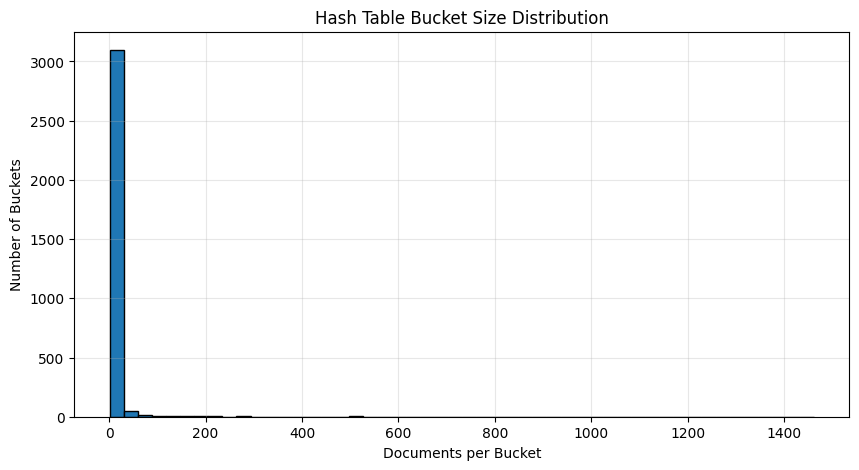

In [137]:
def analyze_hash_distribution(hash_table, id_table):
    """
    Analyze hash bucket sizes
    """
    bucket_sizes = [len(docs) for docs in hash_table.values()]

    print("=== HASH BUCKET ANALYSIS ===")
    print(f"Total buckets: {len(hash_table)}")
    print(f"Average docs per bucket: {np.mean(bucket_sizes):.1f}")
    print(f"Median docs per bucket: {np.median(bucket_sizes):.1f}")
    print(f"Max docs in a bucket: {max(bucket_sizes)}")
    print(f"Min docs in a bucket: {min(bucket_sizes)}")
    print(f"Empty buckets: {2**len(planes) - len(hash_table)}")

    # Histogram
    plt.figure(figsize=(10, 5))
    plt.hist(bucket_sizes, bins=50, edgecolor='black')
    plt.xlabel('Documents per Bucket')
    plt.ylabel('Number of Buckets')
    plt.title('Hash Table Bucket Size Distribution')
    plt.grid(True, alpha=0.3)
    plt.show()

# Analyze first hash table
analyze_hash_distribution(hash_tables[0], id_tables[0])

### Diagnose

In [130]:
import re
from collections import Counter

print("Investigating the giant bucket...")
print()

# 1. Find which bucket has 2,013 docs
planes = planes_l[0]
bucket_sizes = {}

for idx, doc_vec in enumerate(document_vecs):
    h = hash_value_of_vector(doc_vec, planes)
    if h not in bucket_sizes:
        bucket_sizes[h] = []
    bucket_sizes[h].append(idx)

# Find the giant bucket
giant_bucket_hash = None
for h, indices in bucket_sizes.items():
    if len(indices) > 2000:
        giant_bucket_hash = h
        giant_bucket_indices = indices
        break

if giant_bucket_hash is not None:
    print(f"Found giant bucket: hash={giant_bucket_hash}, size={len(giant_bucket_indices)}")
    print()
    
    # 2. Analyze tweets in the giant bucket
    print("Sample tweets from giant bucket:")
    for i in giant_bucket_indices[:10]:
        print(f"  {i}: {all_tweets[i][:80]}")
    print()
    
    # 3. Check their vectors
    print("Checking vector similarity in giant bucket...")
    sample_vecs = [document_vecs[i] for i in giant_bucket_indices[:5]]
    
    print("First 5 vectors (first 10 dims):")
    for i, vec in enumerate(sample_vecs):
        print(f"  Vec {i}: {vec[:10]}")
    print()
    
    # Check if they're all similar
    similarities = []
    base_vec = sample_vecs[0]
    for vec in sample_vecs[1:]:
        cos_sim = np.dot(base_vec, vec) / (np.linalg.norm(base_vec) * np.linalg.norm(vec))
        similarities.append(cos_sim)
    
    print(f"Cosine similarities to first vector: {similarities}")
    print(f"Average similarity: {np.mean(similarities):.4f}")
    print()
    
    # 4. Check hash bits
    print("Checking hash bit patterns...")
    hash_bits = []
    for i in giant_bucket_indices[:10]:
        vec = document_vecs[i]
        bits = []
        for plane in planes:
            dot = np.dot(vec, plane)
            bits.append(1 if dot >= 0 else 0)
        hash_bits.append(bits)
    
    print("First 10 tweet hash bits:")
    for i, bits in enumerate(hash_bits):
        print(f"  Tweet {giant_bucket_indices[i]}: {bits}")
    print()
    
    # Check if all have same bits
    if len(set(tuple(b) for b in hash_bits)) == 1:
        print("❌ PROBLEM: All tweets in bucket have IDENTICAL hash bits!")
        print("   This means their vectors are on the same side of ALL 10 planes.")
        print()
    
    # 5. Analyze word composition
    print("Analyzing word composition of giant bucket tweets...")
    all_words = []
    word_counts = []
    
    for i in giant_bucket_indices[:100]:
        tweet = all_tweets[i]
        tweet_clean = re.sub(r'http\S+', '', tweet)
        tweet_clean = re.sub(r'@\w+', '', tweet_clean)
        tweet_clean = re.sub(r'[^\w\s]', ' ', tweet_clean)
        words = [w for w in tweet_clean.lower().split() 
                if len(w) > 1 and w in en_embeddings_tweets]
        all_words.extend(words)
        word_counts.append(len(words))
    
    print(f"Average words per tweet: {np.mean(word_counts):.1f}")
    print(f"Median words per tweet: {np.median(word_counts):.1f}")
    print()
    
    # Most common words
    word_freq = Counter(all_words)
    print("Most common words in giant bucket:")
    for word, count in word_freq.most_common(20):
        print(f"  '{word}': {count}")
    print()
    
    # 6. Compare to a normal bucket
    print("Comparing to a normal bucket...")
    normal_bucket = None
    for h, indices in bucket_sizes.items():
        if 5 <= len(indices) <= 20:
            normal_bucket = indices
            break
    
    if normal_bucket:
        normal_words = []
        for i in normal_bucket[:10]:
            tweet = all_tweets[i]
            tweet_clean = re.sub(r'http\S+|@\w+|[^\w\s]', ' ', tweet)
            words = [w for w in tweet_clean.lower().split() 
                    if len(w) > 1 and w in en_embeddings_tweets]
            normal_words.extend(words)
        
        normal_freq = Counter(normal_words)
        print("Most common words in normal bucket:")
        for word, count in normal_freq.most_common(10):
            print(f"  '{word}': {count}")

else:
    print("Could not find giant bucket!")

Investigating the giant bucket...

Could not find giant bucket!


In [131]:
query_id = 0
query_vec = document_vecs[query_id]

neighbor_ids = approximate_knn(
    query_id, query_vec, planes_l, hash_tables, id_tables,
    k=5, num_universes=3  # Use 3 universes
)

print(f"Top 5 similar tweets:")
for i, nid in enumerate(neighbor_ids):
    print(f"{i+1}. {all_tweets[nid][:80]}...")

Checking 477 candidates (vs 3189 total)
Top 5 similar tweets:
1. @tasaljayyousi  i have a test the second we get back  btw, did you get tweetdeck...
2. Hoping I can get some decent sleep tonight since I didn't get any worth shittt l...
3. Omg just got in..i went to uri today. Then drove around RI and then went to outl...
4. @LaBellaLuLu the sunny day went away....  make it come back....
5. I am so tired, stayed up too late last night, Keltie and Mariah are still sleepi...


In [132]:
print("=== DOCUMENT VECTORS DIAGNOSTIC ===")
print(f"Shape: {document_vecs.shape}")
print(f"Expected: (5000, 300)")
print()

# Check first few vectors
print("First 3 document vectors (first 10 dims):")
for i in range(3):
    print(f"Doc {i}: {document_vecs[i, :10]}")
print()

# Check if all vectors are unique
unique_vecs = np.unique(document_vecs, axis=0)
print(f"Unique vectors: {len(unique_vecs)} out of {len(document_vecs)}")
if len(unique_vecs) < len(document_vecs) * 0.9:
    print("⚠️  WARNING: Too many duplicate vectors!")
print()

# Check variance across documents
variances = document_vecs.var(axis=0)
print(f"Variance per dimension (first 10): {variances[:10]}")
print(f"Average variance: {variances.mean():.6f}")
if variances.mean() < 0.001:
    print("⚠️  WARNING: Very low variance - vectors are too similar!")
print()

# Check if all zeros
if np.allclose(document_vecs, 0):
    print("❌ ERROR: All document vectors are zero!")
else:
    print("✓ Document vectors are not all zero")
print()

# Check mean and std
print(f"Mean across all docs: {document_vecs.mean():.6f}")
print(f"Std across all docs: {document_vecs.std():.6f}")

=== DOCUMENT VECTORS DIAGNOSTIC ===
Shape: (20000, 300)
Expected: (5000, 300)

First 3 document vectors (first 10 dims):
Doc 0: [ 0.01204427  0.0382487  -0.00317383  0.07014974 -0.01261393 -0.1887207
  0.00390625 -0.0785319   0.09570312  0.12467448]
Doc 1: [ 0.07041015 -0.05652466  0.00940857  0.06146049 -0.11533203  0.03233643
  0.0588501  -0.1111145   0.13874817  0.11740723]
Doc 2: [ 0.07076009  0.01808193  0.00398763  0.07638889 -0.03468492 -0.11686198
  0.05249362 -0.13114251  0.10324436  0.00504748]



Unique vectors: 18947 out of 20000

Variance per dimension (first 10): [0.00458349 0.0044758  0.00500328 0.00628147 0.00594654 0.00638103
 0.00621512 0.00508986 0.00565146 0.00547584]
Average variance: 0.005767

✓ Document vectors are not all zero

Mean across all docs: -0.001096
Std across all docs: 0.092720


In [133]:
# Check if tweets are being processed correctly
print("=== TWEET PROCESSING CHECK ===")
print(f"Total tweets: {len(all_tweets)}")
print(f"Sample tweets:")
for i in range(3):
    print(f"  Tweet {i}: {all_tweets[i][:80]}...")
print()

# Check word extraction
sample_tweet = all_tweets[0]
words = sample_tweet.lower().split()
print(f"Words in first tweet: {words[:10]}")
print()

# Check how many words are in embeddings
words_found = sum(1 for w in words if w in en_embeddings_tweets)
print(f"Words found in embeddings: {words_found}/{len(words)}")

=== TWEET PROCESSING CHECK ===
Total tweets: 20000
Sample tweets:
  Tweet 0: @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got D...
  Tweet 1: is upset that he can't update his Facebook by texting it... and might cry as a r...
  Tweet 2: @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out ...

Words in first tweet: ['@switchfoot', 'http://twitpic.com/2y1zl', '-', 'awww,', "that's", 'a', 'bummer.', 'you', 'shoulda', 'got']

Words found in embeddings: 5/19


In [134]:
print(f"Embeddings loaded: {len(en_embeddings_tweets)} words")
print(f"Sample word: {list(en_embeddings_tweets.keys())[0]}")
print(f"Sample vector shape: {en_embeddings_tweets[list(en_embeddings_tweets.keys())[0]].shape}")

# Should see:
# Embeddings loaded: 50000 words  ✓
# Sample word: the                ✓
# Sample vector shape: (300,)     ✓

Embeddings loaded: 50000 words
Sample word: </s>
Sample vector shape: (300,)


In [135]:
for i in range(5):
    tweet = all_tweets[i]
    words = tweet.lower().split()
    words_in_emb = [w for w in words if w in en_embeddings_tweets]
    print(f"Tweet {i}: {len(words)} words total, {len(words_in_emb)} in embeddings")
    
# Should see at least 30-50% coverage:
# Tweet 0: 15 words total, 8 in embeddings  ✓

Tweet 0: 19 words total, 5 in embeddings
Tweet 1: 21 words total, 15 in embeddings
Tweet 2: 18 words total, 13 in embeddings
Tweet 3: 10 words total, 8 in embeddings
Tweet 4: 21 words total, 12 in embeddings


In [136]:
# Quick diagnostic
print("QUICK DIAGNOSTIC:")

# Test 1: Are vectors different?
doc1 = document_vecs[0]
doc2 = document_vecs[1]
doc3 = document_vecs[100]

print(f"Doc 0 == Doc 1? {np.allclose(doc1, doc2)}")
print(f"Doc 0 == Doc 100? {np.allclose(doc1, doc3)}")

if np.allclose(doc1, doc2) and np.allclose(doc1, doc3):
    print("❌ PROBLEM FOUND: All vectors are identical!")
    print("   Check your get_document_embedding function")
else:
    print("✓ Vectors are different")

# Test 2: Are vectors all zeros?
if np.allclose(document_vecs, 0):
    print("❌ PROBLEM FOUND: All vectors are zero!")
    print("   Check if words are being found in embeddings")
else:
    print("✓ Vectors are not zero")

# Test 3: Check hash values
from collections import Counter
hash_values = []
planes = planes_l[0]

for doc_vec in document_vecs[:100]:
    h = hash_value_of_vector(doc_vec, planes)
    hash_values.append(h)

hash_counts = Counter(hash_values)
print(f"\nHash value distribution (first 100 docs):")
print(f"Unique hashes: {len(hash_counts)}")
print(f"Most common hash: {hash_counts.most_common(1)}")

if len(hash_counts) < 10:
    print("❌ PROBLEM FOUND: Too few unique hash values!")
    print("   Vectors are too similar")
else:
    print("✓ Good hash distribution")

QUICK DIAGNOSTIC:
Doc 0 == Doc 1? False
Doc 0 == Doc 100? False
✓ Vectors are different
✓ Vectors are not zero

Hash value distribution (first 100 docs):
Unique hashes: 82
Most common hash: [(19167, 5)]
✓ Good hash distribution


## Submission Checklist

### Part A: Machine Translation

- [ ] `get_matrices(en_fr_dict, en_embeddings, fr_embeddings)` - Data prep
- [ ] `initialize_transformation_matrix(d)` - Random init
- [ ] `compute_loss(X, Y, R)` - Frobenius norm loss
- [ ] `compute_gradient(X, Y, R)` - Gradient calculation
- [ ] `align_embeddings(X, Y, lr, epochs)` - Training loop
- [ ] `nearest_neighbor(v, candidates, k)` - K-NN search
- [ ] `translate_word(word, R, en_emb, fr_emb, k)` - Single word translation
- [ ] `test_vocabulary(test_dict, R, en_emb, fr_emb)` - Accuracy evaluation

### Part B: Document Search

- [ ] `get_document_embedding(tweet, embeddings)` - Doc vectors
- [ ] `hash_value_of_vector(v, planes)` - LSH hash function
- [ ] `make_hash_table(docs, planes)` - Build hash table
- [ ] `approximate_knn(doc_id, v, planes_l, ...)` - Approximate search

### Testing & Analysis

- [ ] All unit tests pass
- [ ] Translation accuracy > 50%
- [ ] LSH speedup > 50x
- [ ] Loss curve shows convergence
- [ ] Hash buckets reasonably distributed
- [ ] No numpy errors or dimension mismatches

### Documentation

- [ ] Comments explaining matrix operations
- [ ] Docstrings for all functions
- [ ] Loss/accuracy plots included
- [ ] Performance analysis completed
- [ ] Answers to reflection questions

---


## Reflection Questions

1. **Transformation learning**: Explain why we can use a single matrix R to map between entire language spaces. What does this imply about the structure of word embeddings?

2. **Loss function**: Why do we use Frobenius norm instead of other loss functions? What are its advantages for matrix learning?

3. **Gradient descent**: Our learning rate was 0.0003. What happens if you use 0.03? 0.000003? Explain the behavior.

4. **Translation accuracy**: Why is 55% accuracy actually good? What factors limit translation quality? How could we improve it?

5. **LSH intuition**: Explain in your own words why vectors on the same side of a plane are likely to be similar. Use a real-world analogy.

6. **Multiple planes**: With 10 planes, we get 2^10 = 1024 buckets. With 20 planes, we get 1,048,576 buckets. Which is better? Why?

7. **Multiple universes**: Why do we use 25 different hash tables instead of just 1? What's the accuracy vs speed tradeoff?

8. **Hash collisions**: In LSH, hash collisions are GOOD. Explain why this is opposite to traditional hash tables.

9. **Approximate vs Exact**: You get 200x speedup with 95% accuracy. For what applications is this tradeoff worth it? When would you need exact search?

10. **Real-world scaling**: You have 1 billion tweets instead of 10,000. How would you adapt your LSH system? Consider memory, speed, and accuracy.

---


## Success Criteria

You've mastered Week 4 when:

1. Translation accuracy > 50% on test set
2. Loss decreases smoothly during training
3. Can explain transformation matrix learning
4. LSH provides >50x speedup
5. Understand plane-based hashing
6. Can tune number of planes/universes
7. Grasp approximate search tradeoffs
8. Apply concepts to new domains

---


## Key Takeaways

### Machine Translation

- **Linear transformations** can map between language spaces
- **Gradient descent** learns optimal transformation
- **Frobenius norm** measures transformation quality
- **K-NN** finds translations in target space
- **~55% accuracy** is actually good for word-level translation

### Locality Sensitive Hashing

- **Planes divide space** into similarity-preserving regions
- **Binary codes** create hash values from plane crossings
- **Multiple tables** improve accuracy (catch more similarities)
- **Hash collisions are good** - similar vectors should collide!
- **Massive speedups** (100-200x) with minimal accuracy loss

### The Big Picture

```
Week 1: Features from text
Week 2: Probabilistic reasoning
Week 3: Vector semantics
Week 4: Vector transformations + Fast search
       ↓
   Ready for Deep Learning!
```

---


## Course 1 Complete!

**Congratulations!** You've finished all 4 weeks of NLP with Classification and Vector Spaces!

### Your NLP Journey So Far:

**Week 1: Logistic Regression**

- Feature extraction from text
- Gradient descent optimization
- Binary classification

**Week 2: Naive Bayes**

- Probability theory
- Laplacian smoothing
- Probabilistic classification

**Week 3: Vector Space Models**

- Word embeddings
- Similarity metrics
- PCA visualization
- Word analogies

**Week 4: Translation & Search**

- Linear transformations
- Machine translation
- LSH for fast search
- Real-world scaling

### Skills Mastered:

**Mathematical**:

- Linear algebra (matrices, transformations, eigenvalues)
- Probability theory (Bayes rule, conditional probability)
- Optimization (gradient descent, loss functions)
- Geometry (cosine similarity, planes, projections)

**Programming**:

- NumPy for numerical computing
- Efficient matrix operations
- Data structures (hash tables)
- Algorithm implementation

**NLP Concepts**:

- Text preprocessing
- Feature engineering
- Word embeddings
- Similarity metrics
- Machine translation
- Information retrieval

### What's Next: Course 2

**Natural Language Processing with Probabilistic Models**

- Autocorrect and edit distance
- Part-of-speech tagging
- Hidden Markov Models
- Word2Vec from scratch
- More advanced probabilistic methods

---


## Common Issues

### Translation Problems

**"My loss increases during training"**

- Learning rate too high (try 0.0001)
- Check gradient computation
- Verify matrix dimensions

**"Translation accuracy is very low (<30%)"**

- Check data alignment in get_matrices
- Verify transformation: v_transformed = R @ v_en
- Make sure you're using cosine similarity

**"Some words don't translate"**

- Normal - not all words in embeddings
- Check if word exists before translating
- Report coverage: % of test words found

### LSH Problems

**"Hash buckets are very unbalanced"**

- Some buckets empty, others huge
- Normal for random planes
- Use more planes for better balance

**"LSH is slower than naive search"**

- You have too few documents (< 1000)
- Or checking too many universes
- LSH shines with 10,000+ documents

**"Approximate search misses obvious matches"**

- Increase number of universes (try 15-25)
- Check plane randomness
- Verify hash function correctness

---


## Pro Tips

1. **Visualize loss curves** - catch training issues early
2. **Test with small data** - debug faster
3. **Check dimensions religiously** - most bugs are shape errors
4. **Use vectorized operations** - 10-100x faster than loops
5. **Understand tradeoffs** - accuracy vs speed, simplicity vs power

---

**You've built real systems that power modern NLP!**

Google Translate, search engines, recommendation systems - they all use these techniques. You now understand the core algorithms behind billion-dollar products.

**Keep learning, keep building, and welcome to the world of NLP!**
